In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, roc_curve
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

### 3. Część 1

In [ ]:
df_X = pd.read_csv("https://raw.githubusercontent.com/kozaka93/2025Z-MachineLearning/refs/heads/main/homeworks/homework2/df_X.csv")
df_y = pd.read_csv("https://raw.githubusercontent.com/kozaka93/2025Z-MachineLearning/refs/heads/main/homeworks/homework2/df_y.csv")
df_X = df_X.drop(["Unnamed: 0"], axis=1)
df_y = df_y.drop(["Unnamed: 0"], axis=1)
#df_X.info()
#df_y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1537 entries, 0 to 1536
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X0      1537 non-null   int64  
 1   X1      1537 non-null   int64  
 2   X2      1507 non-null   float64
 3   X3      1537 non-null   int64  
 4   X4      1537 non-null   int64  
 5   X5      1537 non-null   int64  
 6   X6      1537 non-null   int64  
 7   X7      1537 non-null   int64  
 8   X8      1461 non-null   float64
 9   X9      1537 non-null   int64  
 10  X10     1537 non-null   int64  
 11  X11     1537 non-null   int64  
 12  X12     1537 non-null   int64  
 13  X13     1537 non-null   int64  
 14  X14     1537 non-null   int64  
 15  X15     1537 non-null   int64  
 16  X16     1537 non-null   int64  
 17  X17     1537 non-null   int64  
 18  X18     1537 non-null   int64  
 19  X19     1537 non-null   int64  
 20  X20     1537 non-null   object 
 21  X21     1537 non-null   object 
dtype

In [4]:
A = df_X.join(df_y)
A = A.dropna()
A = pd.get_dummies(A)
X = A.drop(["y"], axis=1)
y = A.y
#X.info()
#y.info()

In [5]:
X_train_0, X_test_0, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=333063)
#X_train.info()
#X_test.info()
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_0)
X_test = scaler.transform(X_test_0)

In [6]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
L1_ratio_values = [0.1, 0.5, 0.9]

model_1 = LogisticRegression(penalty=None, max_iter=2000)
model_2 = LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000)
model_3 = LogisticRegression(penalty="l2", max_iter=2000)
model_4 = LogisticRegression(penalty="elasticnet", solver="saga", max_iter=2000)

grid_model_1 = GridSearchCV(model_1, {"C": [1]}, cv=10, scoring="roc_auc", n_jobs=-1)
grid_model_2 = GridSearchCV(model_2, {"C": C_values}, cv=10, scoring="roc_auc", n_jobs=-1)
grid_model_3 = GridSearchCV(model_3, {"C": C_values}, cv=10, scoring="roc_auc", n_jobs=-1)
grid_model_4 = GridSearchCV(model_4, {"C": C_values, "l1_ratio": L1_ratio_values}, cv=10, scoring="roc_auc", n_jobs=-1)

models = {
    "1. Regresja Logistyczna": grid_model_1,
    "2. Regresja Logistyczna (L1)": grid_model_2,
    "3. Regresja Logistyczna (L2)": grid_model_3,
    "4. Regresja Logistyczna (elasticnet)": grid_model_4}
results_train = pd.DataFrame(columns=["Model", "Dokładność", "Czułość", "Precyzja", "AUC"])
results_test = pd.DataFrame(columns=["Model", "Dokładność", "Czułość", "Precyzja", "AUC"])
results_coefs_train, results_coefs_test = [], []
results_intercepts_train, results_intercepts_test = [], []

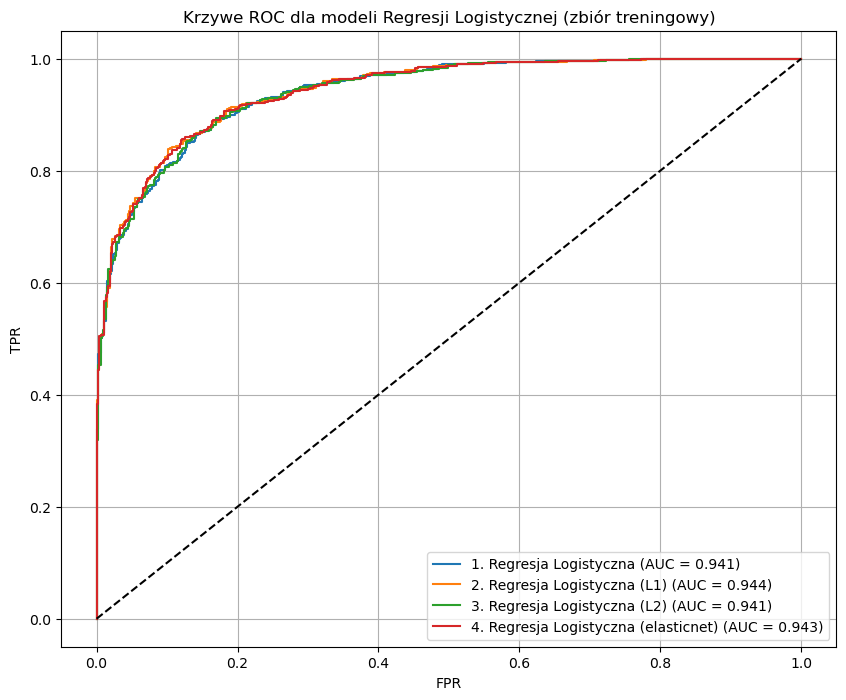

In [6]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = cross_val_predict(model, X_train, y_train, cv=10, method="predict_proba")[:,1]
    y_pred = (y_proba>=0.5).astype(int)
    acc_train = accuracy_score(y_train, y_pred)
    rec_train = recall_score(y_train, y_pred)
    prec_train = precision_score(y_train, y_pred)
    auc_train = roc_auc_score(y_train, y_proba)
    results_train.loc[len(results_train)] = [name, acc_train, rec_train, prec_train, auc_train]
    best_model = model.best_estimator_
    results_coefs_train.append(best_model.coef_[0])
    results_intercepts_train.append(best_model.intercept_[0])
    fpr, tpr, _ = roc_curve(y_train, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_train:.3f})")

plt.title("Krzywe ROC dla modeli Regresji Logistycznej (zbiór treningowy)")
plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid(True)
plt.show()

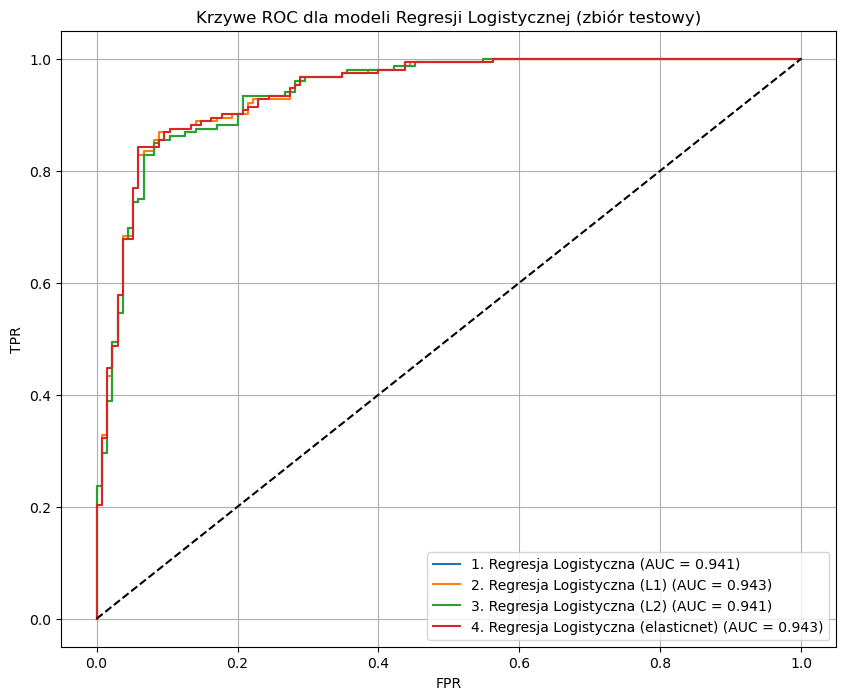

In [7]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred)
    rec_test = recall_score(y_test, y_pred)
    prec_test = precision_score(y_test, y_pred)
    auc_test = roc_auc_score(y_test, y_proba)
    results_test.loc[len(results_test)] = [name, acc_test, rec_test, prec_test, auc_test]
    best_model = model.best_estimator_
    results_coefs_test.append(best_model.coef_[0])
    results_intercepts_test.append(best_model.intercept_[0])
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_test:.3f})")

plt.title("Krzywe ROC dla modeli Regresji Logistycznej (zbiór testowy)")
plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid(True)
plt.show()

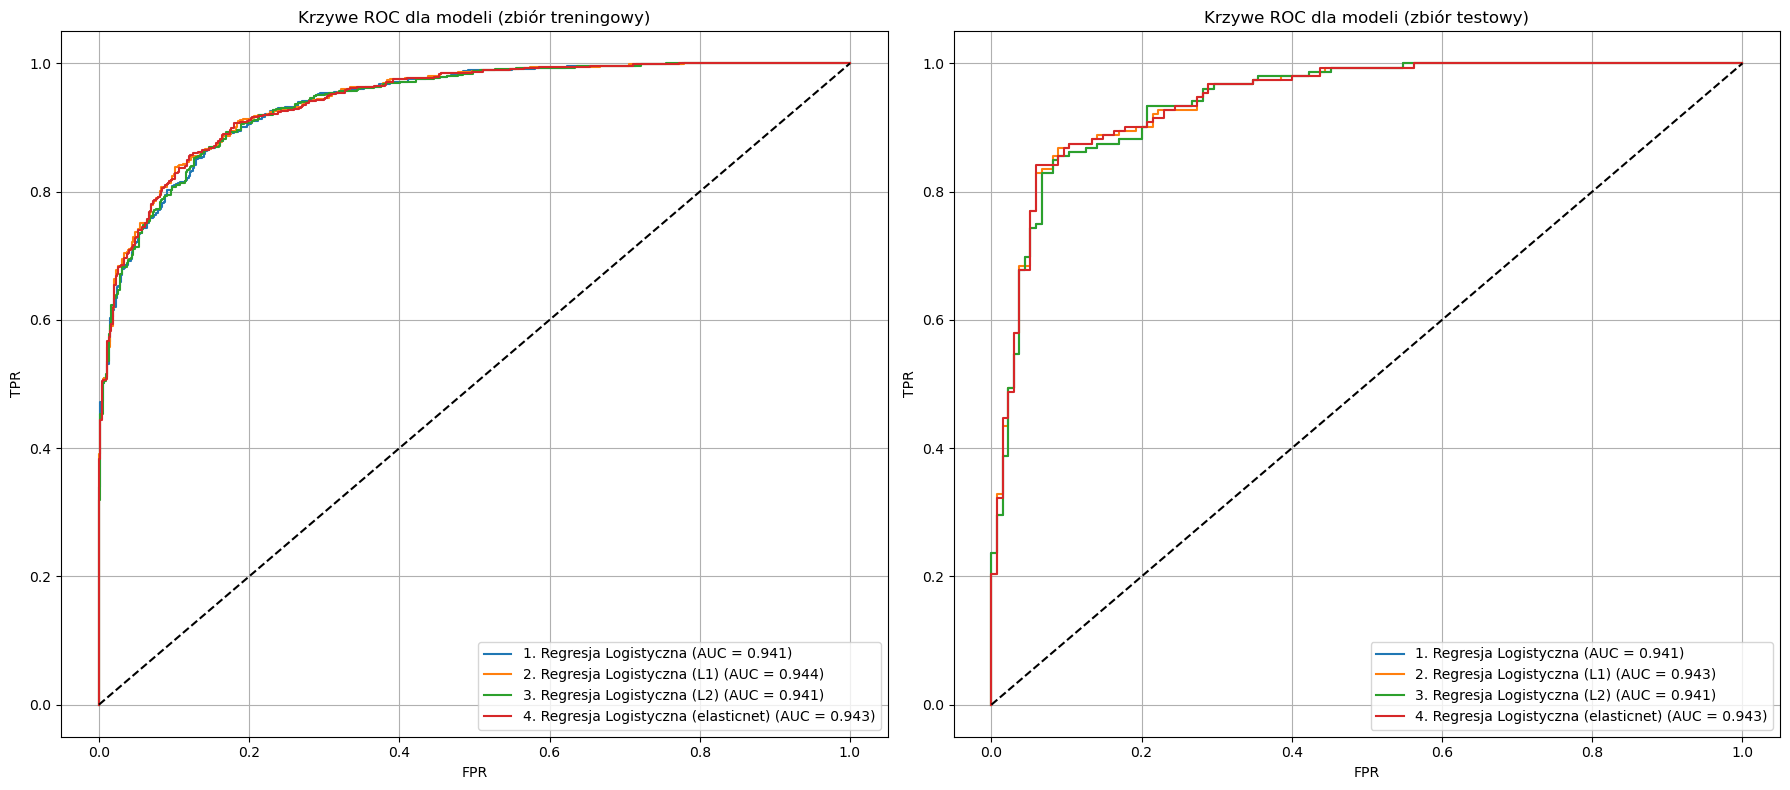

In [17]:
fig, (ax_train, ax_test) = plt.subplots(1, 2, figsize=(18, 8))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = cross_val_predict(model, X_train, y_train, cv=10, method="predict_proba")[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    auc_train = roc_auc_score(y_train, y_proba)
    fpr, tpr, _ = roc_curve(y_train, y_proba)
    ax_train.plot(fpr, tpr, label=f"{name} (AUC = {auc_train:.3f})")

ax_train.set_title("Krzywe ROC dla modeli (zbiór treningowy)")
ax_train.legend(loc="lower right")
ax_train.plot([0, 1], [0, 1], "k--")
ax_train.set_xlabel("FPR")
ax_train.set_ylabel("TPR")
ax_train.grid(True)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    auc_test = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax_test.plot(fpr, tpr, label=f"{name} (AUC = {auc_test:.3f})")

ax_test.set_title("Krzywe ROC dla modeli (zbiór testowy)")
ax_test.legend(loc="lower right")
ax_test.plot([0, 1], [0, 1], "k--")
ax_test.set_xlabel("FPR")
ax_test.set_ylabel("TPR")
ax_test.grid(True)

plt.tight_layout()
plt.show()

In [8]:
print("Najlepsze C dla modelu 2:", grid_model_2.best_params_)
print("Najlepsze C dla modelu 3:", grid_model_3.best_params_)
print("Najlepsze C i l1_ratio dla modelu 4:", grid_model_4.best_params_)

Najlepsze C dla modelu 2: {'C': 0.1}
Najlepsze C dla modelu 3: {'C': 1000}
Najlepsze C i l1_ratio dla modelu 4: {'C': 0.1, 'l1_ratio': 0.9}


In [9]:
results_train

,Model,Dokładność,Czułość,Precyzja,AUC
0,1. Regresja Logistyczna,0.858515,0.878536,0.855754,0.940959
1,2. Regresja Logistyczna (L1),0.861135,0.885191,0.855305,0.943740
2,3. Regresja Logistyczna (L2),0.857642,0.878536,0.854369,0.941027
3,4. Regresja Logistyczna (elasticnet),0.863755,0.890183,0.856000,0.943253


In [10]:
results_test

,Model,Dokładność,Czułość,Precyzja,AUC
0,1. Regresja Logistyczna,0.853659,0.875000,0.852564,0.940741
1,2. Regresja Logistyczna (L1),0.871080,0.881579,0.875817,0.942641
2,3. Regresja Logistyczna (L2),0.853659,0.875000,0.852564,0.940741
3,4. Regresja Logistyczna (elasticnet),0.867596,0.881579,0.870130,0.942690


In [ ]:
for _ in results_coefs_train:
    print(_)
print(results_intercepts_train)

[ 2.02413525 -1.21334094  1.02488188  0.7402407  -1.02002893  1.2181117
  2.73137833 -0.29283934  0.13460896 -0.04004951  0.04555773  0.00600456
 -1.37991305  0.12060914 -0.00617499 -0.07444716  0.90278497 -0.03092636
  0.07006296 -1.59544901  0.01618721 -0.11028319  0.09341773  0.04304846
  0.04849853 -0.09075991]
[ 1.48176912 -0.78553035  0.71115614  0.52057953 -0.69789432  0.86238086
  1.88141689  0.          0.03713862  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.         -0.23668355  0.          0.
  0.          0.        ]
[ 2.02395445 -1.2131125   1.0248054   0.74019495 -1.01992069  1.21799923
  2.73094453 -0.29177377  0.13459187 -0.04008475  0.04550501  0.00599236
 -1.37499532  0.12059088 -0.00618506 -0.07440226  0.89976681 -0.03092586
  0.07005117 -1.58967162  0.01629204 -0.11040099  0.09342986  0.04302941
  0.04847051 -0.09071327]
[ 1.47197308 -0.76936022  0.71236629  0.5241883  -0.69896407  0.8624400

In [14]:
for _ in results_coefs_test:
    print(_)
print(results_intercepts_test)

[ 2.02413525 -1.21334094  1.02488188  0.7402407  -1.02002893  1.2181117
  2.73137833 -0.29283934  0.13460896 -0.04004951  0.04555773  0.00600456
 -1.37991305  0.12060914 -0.00617499 -0.07444716  0.90278497 -0.03092636
  0.07006296 -1.59544901  0.01618721 -0.11028319  0.09341773  0.04304846
  0.04849853 -0.09075991]
[ 1.48185151 -0.78573145  0.711171    0.52051812 -0.69787363  0.86241308
  1.88179608  0.          0.03713267  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.         -0.23659517  0.          0.
  0.          0.        ]
[ 2.02395445 -1.2131125   1.0248054   0.74019495 -1.01992069  1.21799923
  2.73094453 -0.29177377  0.13459187 -0.04008475  0.04550501  0.00599236
 -1.37499532  0.12059088 -0.00618506 -0.07440226  0.89976681 -0.03092586
  0.07005117 -1.58967162  0.01629204 -0.11040099  0.09342986  0.04302941
  0.04847051 -0.09071327]
[ 1.47194501 -0.76929599  0.71236998  0.52419907 -0.69895627  0.8624287

### 4. Część 2

In [9]:
SVM_model = SVC(kernel="linear", C=1, probability=True, random_state=333063)
SVM_model.fit(X_train, y_train)

SVC(C=1, kernel='linear', probability=True, random_state=333063)

Wyniki modelu SVM_model:

1) dla zbioru treningowego:
	DokładnośC: 0.868995633187773
	Czułość: 0.8868552412645591
	Precyzja: 0.8666666666666667
	Wartość AUC: 0.9473732504649114

2) dla zbioru testowego:
	Dokładność: 0.8397212543554007
	tCzułość: 0.875
	Precyzja: 0.83125
	Wartość AUC: 0.9389619883040936



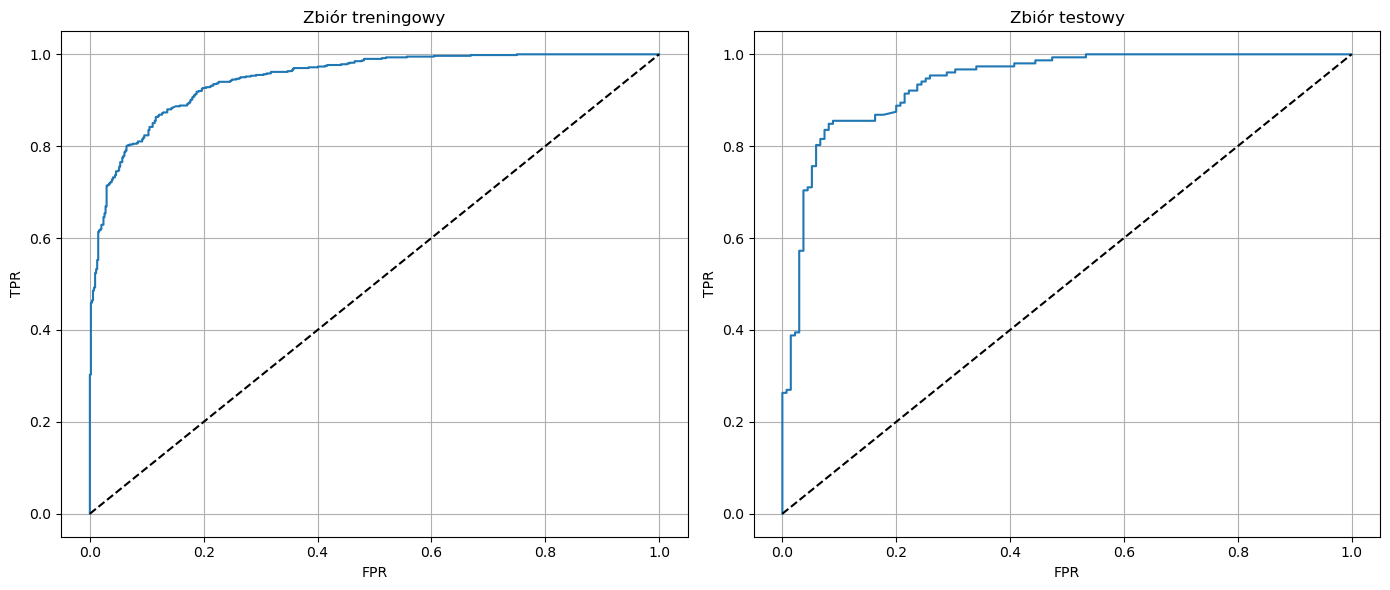

In [11]:
y_train_proba = SVM_model.predict_proba(X_train)[:,1]
y_train_pred = (y_train_proba >= 0.5).astype(int)
acc_train = accuracy_score(y_train, y_train_pred)
rec_train = recall_score(y_train, y_train_pred)
prec_train = precision_score(y_train, y_train_pred)
auc_train = roc_auc_score(y_train, y_train_proba)

y_test_proba = SVM_model.predict_proba(X_test)[:,1]
y_test_pred = (y_test_proba >= 0.5).astype(int)
acc_test = accuracy_score(y_test, y_test_pred)
rec_test = recall_score(y_test, y_test_pred)
prec_test = precision_score(y_test, y_test_pred)
auc_test = roc_auc_score(y_test, y_test_proba)

print("Wyniki modelu SVM_model:\n")
print("1) dla zbioru treningowego:")
print(f"\tDokładnośC: {acc_train}")
print(f"\tCzułość: {rec_train}")
print(f"\tPrecyzja: {prec_train}")
print(f"\tWartość AUC: {auc_train}\n")
print("2) dla zbioru testowego:")
print(f"\tDokładność: {acc_test}")
print(f"\ttCzułość: {rec_test}")
print(f"\tPrecyzja: {prec_test}")
print(f"\tWartość AUC: {auc_test}\n")

fpr_train, tpr_train, thr_train = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, thr_test = roc_curve(y_test, y_test_proba)

fig, axes = plt.subplots(1, 2, figsize = (14,6))
axes[0].plot(fpr_train, tpr_train)
axes[1].plot(fpr_test, tpr_test)
    
for ax, title in zip(axes, ["Zbiór treningowy", "Zbiór testowy"]):
    ax.plot([0,1], [0,1], "k--")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(title)
    ax.grid(True)

plt.tight_layout()
plt.savefig("ROC_curve2.pdf", dpi = 300, bbox_inches = "tight")
plt.show()